In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 


In [2]:
import pickle 

manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_neg_15_to_6_dBSNR_eval_rooms.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)

In [3]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')

In [4]:
spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')

In [5]:
spkr_room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"[2.3, 3.6, 0.9]",0,False,"Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Concrete, painted",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[4.66, 5.9, 2.48]","[9, 9, 9, 2, 13, 17]"
1,0,"[3.6, 2.36, 0.9]",1,False,"Fiberglass wall treatment, 1 in","Concrete, painted","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[5.9, 4.66, 2.48]","[9, 2, 9, 9, 13, 17]"
2,0,"[2.36, 2.3, 0.9]",2,False,"Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Concrete, painted","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[4.66, 5.9, 2.48]","[9, 9, 2, 9, 13, 17]"
3,0,"[2.3, 2.3, 0.9]",3,False,"Concrete, painted","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in","Fiberglass wall treatment, 1 in",Linoleum,"Acoustic tiles, 0.625"", 16"" below ceiling","[5.9, 4.66, 2.48]","[2, 9, 9, 9, 13, 17]"


In [6]:
ls /om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004

manifest_brir.pdpkl  room0000.hdf5  room0002.hdf5
manifest_room.pdpkl  room0001.hdf5  room0003.hdf5


In [7]:
room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"(2.5, 2.5, 2.0)",0,False,"(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(Anechoic,)","(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)"
1,0,"(2.5, 2.5, 2.0)",1,False,"(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Wood panelling on glass fiber blanket,)","(Carpet on foam rubber padding,)","(Highly absorptive panels, 1"", 16"" below ceili...","(5.0, 5.0, 4.0)","(11, 11, 11, 11, 15, 20)"
2,0,"(2.5, 2.5, 2.0)",2,False,"(Brick,)","(Brick,)","(Brick,)","(Brick,)","(Wood parquet on concrete,)","(Plaster, gypsum, or lime on lath,)","(5.0, 5.0, 4.0)","(1, 1, 1, 1, 12, 16)"
3,0,"(2.5, 2.5, 2.0)",3,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(5.0, 5.0, 4.0)","(9, 9, 9, 9, 13, 17)"
4,0,"(2.5, 2.5, 2.0)",4,False,"(Concrete, painted,)","(Concrete, painted,)","(Concrete, painted,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(5.0, 5.0, 4.0)","(2, 2, 2, 2, 13, 17)"
5,0,"(2.3, 3.6, 0.9)",5,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 2, 13, 17)"
6,0,"(2.33, 2.95, 0.9)",6,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Concrete, painted,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 2, 13, 17)"
7,0,"(2.3, 3.6, 0.9)",7,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 9, 13, 17)"
8,0,"(2.33, 2.95, 0.9)",8,False,"(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Fiberglass wall treatment, 1 in,)","(Linoleum,)","(Acoustic tiles, 0.625"", 16"" below ceiling,)","(4.66, 5.9, 2.48)","(9, 9, 9, 9, 13, 17)"


In [35]:
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [29]:
row.index_room

8

In [30]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*room*.pkl"))
stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if 'v07' not in path.as_posix() and 'v08' not in path.as_posix():
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    dist_type = 'speech'
    if 'ssn' in path.stem:
        dist_type = 'noise'
    df['dist_type'] = dist_type
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    results_dfs.append(df)
results = pd.concat(results_dfs)


In [36]:
results['room_str'] = results['room_ix'].map(room_material_map)

In [37]:
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [38]:
grouped_results = results.groupby(['model', 'target_azim', 'distractor_azim', 'gender_cond', 'snr', 'dist_type', 'room_ix']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]



In [94]:
## Listen to different BRIRS 
import h5py 
import soxr 
import sys 

sys.path.append('/om2/user/imgriff/datasets/spatial_audio_pipeline/')
from spatial_audio_util import util_audio
import IPython.display as ipd 

def get_brir_examp(h5_fn, manifest, azim=0, elev=0, out_sr=44100):
    df_row = manifest[(manifest['src_azim'] == azim) & (manifest['src_elev'] == elev)]
    index_brir = df_row['index_brir'].values[0]
    sr_src = df_row['sr'].values[0]
    with h5py.File(h5_fn, 'r') as f:
        brir = f['brir'][index_brir]
    if out_sr != sr_src:
        brir = soxr.resample(brir.astype(np.float32), sr_src, out_sr)
    return brir 

# new Room 
h5_path = "/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/room0005.hdf5"
room_brir_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_brir.pdpkl')
room_brir_manifest = room_brir_manifest[room_brir_manifest.index_room==5]
new_brir = get_brir_examp(h5_path, room_brir_manifest)
# old_room
h5_path = "/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/room0000.hdf5"
room_brir_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_brir.pdpkl')
room_brir_manifest = room_brir_manifest[room_brir_manifest.index_room==0]
old_brir = get_brir_examp(h5_path, room_brir_manifest)


# eg signal 
sig = np.sin(2*np.pi*220 * np.linspace(0, 3,  int(3* 44_100)))
sig += np.sin(2*np.pi*320 * np.linspace(0, 3,  int(3* 44_100)))
# sig += np.sin(2*np.pi*110 * np.linspace(0, 3,  int(3* 44_100)))
sig = util_audio.set_dBSPL(sig, 60)
crop_size = int(0.5 * 44100)

old_spatilized  = util_audio.spatialize_sound(sig.copy(), old_brir)
old_spatilized  = old_spatilized[crop_size : -crop_size, :]
old_spatilized  = np.vstack([util_audio.ramp_hann(sig_, 20) for sig_ in old_spatilized.T]).T
new_spatilized  = util_audio.spatialize_sound(sig, new_brir)
new_spatilized  = new_spatilized[crop_size : -crop_size, :]
new_spatilized  = np.vstack([util_audio.ramp_hann(sig_, 20) for sig_ in new_spatilized.T]).T


print('Old room simulation')
ipd.display(ipd.Audio(old_spatilized.T, rate=44_100, normalize=False))
print('New room simulation')
ipd.display(ipd.Audio(new_spatilized.T, rate=44_100, normalize=False))

Old room simulation


New room simulation


(132300, 2)

In [47]:
room_brir_manifest.head()

,buffer,c,dur,head_azim,head_pos_xyz,incorporate_lead_zeros,index_brir,index_room,room_dim_xyz,room_materials,sr,src_azim,src_dist,src_elev,use_highpass,use_hrtf_symmetry,use_jitter,use_log_distance
0,0,344.5,0.5,0,"(2.5, 2.5, 2.0)",True,0,0,"(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)",44100,0,1.4,-40,True,True,True,False
1,0,344.5,0.5,0,"(2.5, 2.5, 2.0)",True,1,0,"(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)",44100,0,1.4,-30,True,True,True,False
2,0,344.5,0.5,0,"(2.5, 2.5, 2.0)",True,2,0,"(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)",44100,0,1.4,-20,True,True,True,False
3,0,344.5,0.5,0,"(2.5, 2.5, 2.0)",True,3,0,"(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)",44100,0,1.4,-10,True,True,True,False
4,0,344.5,0.5,0,"(2.5, 2.5, 2.0)",True,4,0,"(5.0, 5.0, 4.0)","(26, 26, 26, 26, 26, 26)",44100,0,1.4,0,True,True,True,False


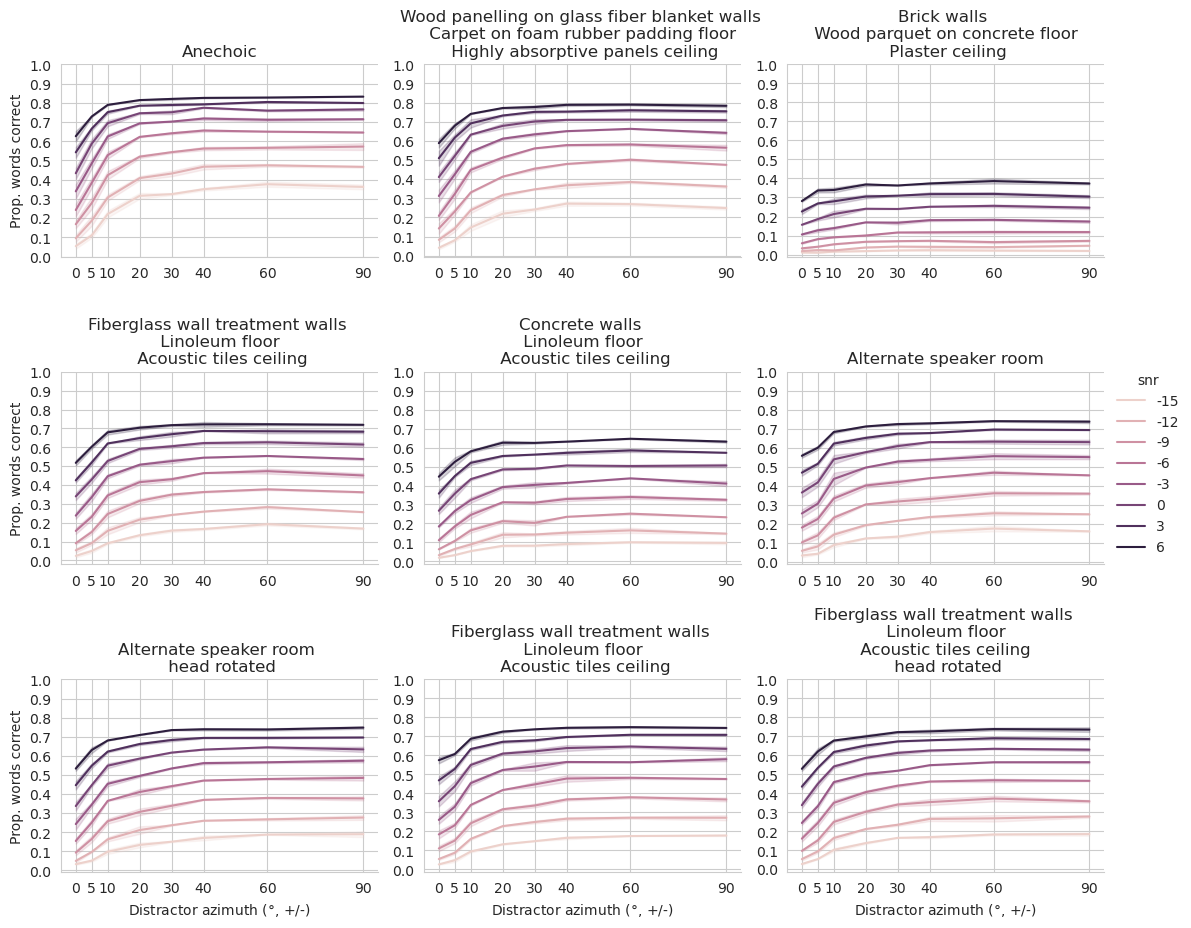

In [40]:

sns.set_style('whitegrid')

to_plot = grouped_results.copy() #& (grouped_results.target_azim == 'center')]
to_plot['distractor_azim'] = to_plot['distractor_azim'].astype(int).abs()

g = sns.relplot(data=to_plot,
                x='distractor_azim', y='accuracy_mean', errorbar=('se', 1), hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='room_ix', col_wrap=3, #row='dist_type',
                # palette=palette, 
                height=3, aspect=1.25)

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Prop. words correct")
g.set_titles("{col_name}")
# plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))

x_tick_locs = np.sort(to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    ax.set_title(f"{room_material_map[int(ax.get_title())]}")
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
# plt.tight_layout()
plt.subplots_adjust(hspace = 0.6)


In [34]:
grouped_results.snr.unique()

array([-15, -12,  -9,  -6,  -3,   0,   3,   6])

[-15 -12  -9  -6  -3   0   3]


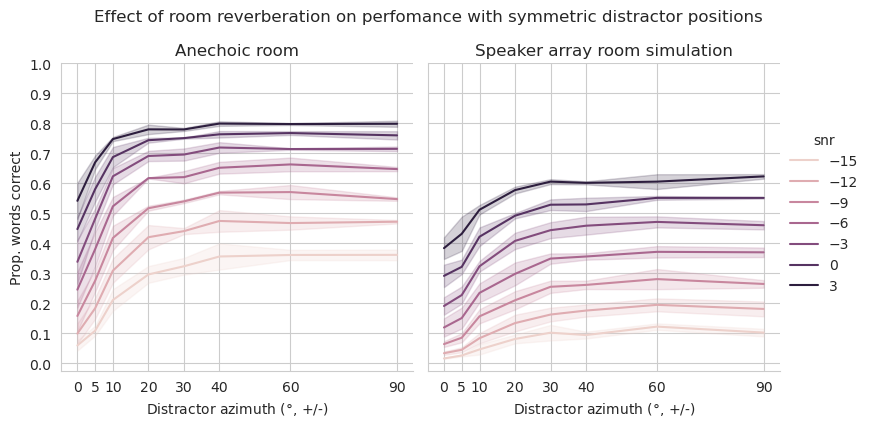

In [8]:
### Plot diotic precedense effect 


# hue_order = ['clean', 'overlap', 'left', 'right', 'center']
# 
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results[grouped_results.model.isin(["word_task_half_co_loc_v07_normal_room", "word_task_half_co_loc_v07"])].copy() #& (grouped_results.target_azim == 'center')]
# to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
# to_plot = to_plot[to_plot.snr >= -6]
to_plot['distractor_azim'] = to_plot['distractor_azim'].astype(int).abs()
# to_plot['snr'] = to_plot['snr'].astype(int)
# to_plot = to_plot[to_plot.distractor_azim <= 40]

print(to_plot.snr.unique())
# g = sns.relplot(data=to_plot,
#                 #palette=palette,
#                 x='distractor_azim', y='accuracy_mean', errorbar=('se', 2),
#                 hue="snr",
#                 kind='line', legend=True,
#                 col='dist_type',
#                 # palette=palette, 
#                 facet_kws={'sharey':False},
#                 height=4)


g = sns.relplot(data=to_plot,
                #palette=palette,
                x='distractor_azim', y='accuracy_mean', errorbar=('se', 2), hue="snr",
                kind='line', legend=True,
                col='model', row='dist_type',
                # palette=palette, 
                height=4)

# iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim']==azim]
#     # select the data for each hue group
#     for group, selected in data.groupby('diotic_cond'):
#         if group != 'clean':
#             continue
#         # plot the errorbar with the correct color for each group 
#         print(group)
#         ax.errorbar(data=selected, x="snr", y="accuracy_mean",
#                      yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Prop. words correct")
# change plot titles 

titles = ["Anechoic room", "Speaker array room simulation"]

plt.suptitle("Effect of room reverberation on perfomance with symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
for ix, ax in enumerate(g.axes.flat):
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    ax.set_title(titles[ix])
# plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

### Make plot for ARO 2024

In [9]:
### Byrne et al. 2023 data 

byrne_data = np.array([-0.09484242924828479, 0.4982925897160886,
                        5.013827763189802, -3.951329561004476,
                        10.05543433148005, -10.226709567661526,
                        19.95734556258245, -13.644653196411767,
                        39.96515321490358, -15.760526975438765,
                        0.022518913010429742, -11.306631162395057,
                        5.0401272236399315, -11.078483342990165,
                        10.065132257521036, -12.854847524768747,
                        19.96030425188309, -14.446457996885155,
                        39.8901997526207, -15.448138696779548]).reshape(-1, 2)
                        
byrne_data = pd.DataFrame({'distractor_azim':byrne_data[:,0], 'threshold_snr':byrne_data[:,1]})
byrne_data['dist_type'] = ["speech"] * 5 + ["noise"] * 5 
byrne_data['distractor_azim'] = byrne_data['distractor_azim'].astype(int).abs()
byrne_data

,distractor_azim,threshold_snr,dist_type
0,0,0.498293,speech
1,5,-3.951330,speech
2,10,-10.226710,speech
3,19,-13.644653,speech
4,39,-15.760527,speech
5,0,-11.306631,noise
6,5,-11.078483,noise
7,10,-12.854848,noise
8,19,-14.446458,noise
9,39,-15.448139,noise


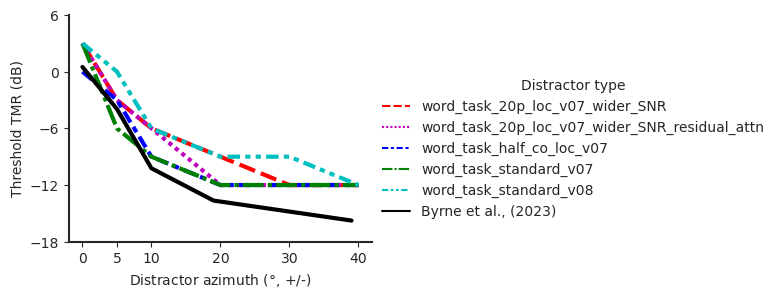

In [12]:
wanted_models = ['word_task_20p_loc_v07_wider_SNR', 'word_task_20p_loc_v07_wider_SNR_residual_attn', 'word_task_half_co_loc_v07', 'word_task_standard_v07', 'word_task_standard_v08']
model_to_plot = grouped_results[grouped_results.model.isin(wanted_models)].copy() #& (grouped_results.target_azim == 'center')]
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].astype(int).abs()
model_to_plot = model_to_plot[model_to_plot.distractor_azim <= 40]

## Get thresholds where performance is 45% 
# get threshold for each target azimuth and dist_type
thresholds = []
for (model, azim, dist_type), group in model_to_plot.groupby(['model', 'distractor_azim', 'dist_type']):
    # print(model)
    threshold_value = model_to_plot[model_to_plot.model == model].accuracy_mean.max() / 2 
    # get the snr where performance is 50% max clean speech performance
    thresh = group[group.accuracy_mean >= .42].snr.min()
    if np.isnan(thresh) or np.isinf(thresh):
        thresh = 6
    # print(thresh)
    thresholds.append((model, azim, dist_type, thresh))

thresholds = pd.DataFrame(thresholds, columns=['model', 'distractor_azim', 'dist_type', 'threshold_snr'])
thresholds['threshold_snr'] = thresholds['threshold_snr'].astype(int)
thresholds['distractor_azim'] = thresholds['distractor_azim'].astype(int)
# thresholds['model'] = "Model"

# add byrne data to model_to_plot
byrne_data['model'] = "Byrne et al., (2023)"
data_to_plot = pd.concat([thresholds, byrne_data], axis=0)
data_to_plot = data_to_plot[data_to_plot.dist_type == 'speech']
# make a palette for noise and speech where speech is black and noise is blue
# palette = {'speech':'k', 'noise':'r'}
palette = {'Byrne et al., (2023)':'k', 'word_task_20p_loc_v07_wider_SNR_residual_attn':'m', 'word_task_20p_loc_v07_wider_SNR':'r',
 'word_task_half_co_loc_v07':'b', 'word_task_standard_v07':'g', 'word_task_standard_v08':'c' }

# col_order = ['Byrne et al., (2023)', 'Model']
sns.set_style('ticks')
# plot 
# g = sns.relplot(data=data_to_plot, x='distractor_azim', y='threshold_snr',
#                 col = 'model', #col_order=col_order,
#                 hue='dist_type', palette=palette, alpha=0.5,
#                 kind='line', linewidth=3, zorder=5, legend=True,
#                 facet_kws={'sharey':False},
#                 errorbar=('se', 2), height=3, aspect=0.75)

g = sns.relplot(data=data_to_plot, x='distractor_azim', y='threshold_snr',
              #  col = 'model',# col_order=col_order,
                hue='model', palette=palette, 
                # alpha=0.5,
                style='model', style_order=['Byrne et al., (2023)'] + wanted_models,
                kind='line', linewidth=3, zorder=5, legend=True,
                facet_kws={'sharey':False},
                errorbar=('se', 2), height=3, aspect=1.5)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set_titles("{col_name}")

# plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(-18,  7, 6))
# g.legend.remove()
g._legend.set_title("Distractor type")
 
# move  legend of g to the right
# g._legend.set_bbox_to_anchor([0.55, 0.6])

x_tick_locs = np.sort(model_to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# save figure as svg 
# outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'symmetric_distractor_thresholds.svg', transparent=True, bbox_inches='tight')

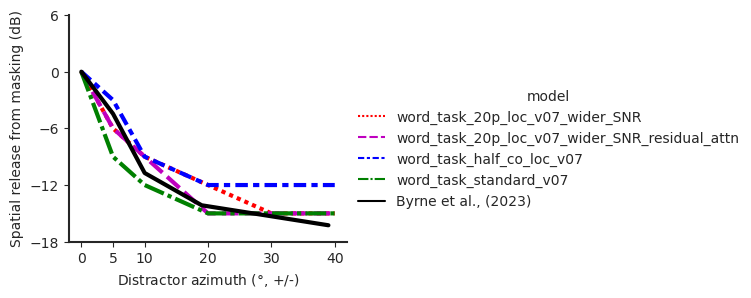

In [11]:
## Plot as spatial release from masking 


wanted_models = ['word_task_20p_loc_v07_wider_SNR', "word_task_20p_loc_v07_wider_SNR_residual_attn", 'word_task_half_co_loc_v07', 'word_task_standard_v07']
model_to_plot = grouped_results[grouped_results.model.isin(wanted_models)].copy() #& (grouped_results.target_azim == 'center')]
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].astype(int).abs()
model_to_plot = model_to_plot[model_to_plot.distractor_azim <= 40]


threshold_value = model_to_plot.accuracy_mean.max() / 2
## Get thresholds where performance is 45% 
# get threshold for each target azimuth and dist_type
thresholds = []
for (model, azim, dist_type), group in model_to_plot.groupby(['model', 'distractor_azim', 'dist_type']):
    # print(model)
    threshold_value = model_to_plot[model_to_plot.model == model].accuracy_mean.max() / 2 
    # get the snr where performance is 50% max clean speech performance
    thresh = group[group.accuracy_mean >= 0.42].snr.min()
    if np.isnan(thresh) or np.isinf(thresh):
        thresh = 6
    # print(thresh)
    thresholds.append((model, azim, dist_type, thresh))

thresholds = pd.DataFrame(thresholds, columns=['model', 'distractor_azim', 'dist_type', 'threshold_snr'])
thresholds['threshold_snr'] = thresholds['threshold_snr'].astype(int)
thresholds['distractor_azim'] = thresholds['distractor_azim'].astype(int)
# thresholds['model'] = "Model"
# get max threshold for each model
for model, group in thresholds.groupby('model'):
    model_max_thresh = group.threshold_snr.max()
    thresholds.loc[thresholds.model == model, 'spatial_release'] =  thresholds.threshold_snr - model_max_thresh

# model_max_thresh = thresholds.threshold_snr.max()
# thresholds['spatial_release'] =  thresholds.threshold_snr - model_max_thresh 

# add byrne data to model_to_plot
byrne_data['model'] = "Byrne et al., (2023)"

byrne_data['spatial_release'] = byrne_data.threshold_snr -  byrne_data.threshold_snr.max()

data_to_plot = pd.concat([thresholds, byrne_data], axis=0)
data_to_plot = data_to_plot[data_to_plot.dist_type == 'speech']
# make palette for models where byrne is black and models are other colors
palette = {'Byrne et al., (2023)':'k', 'word_task_20p_loc_v07_wider_SNR_residual_attn':'m', 'word_task_20p_loc_v07_wider_SNR':'r', 'word_task_half_co_loc_v07':'b', 'word_task_standard_v07':'g'}
# create line styles where byrne is solid and models are dashed
linestyles = {'Byrne et al., (2023)':'-', 'word_task_20p_loc_v07_wider_SNR':'--', 'word_task_half_co_loc_v07':'--', 'word_task_standard_v07':'--'}
# palette = {'speech':'k', 'noise':'r'}
# col_order = ['Byrne et al., (2023)', 'Model']
sns.set_style('ticks')
# plot 
g = sns.relplot(data=data_to_plot, x='distractor_azim', y='spatial_release',
              #  col = 'model',# col_order=col_order,
                hue='model', palette=palette, 
                # alpha=0.5,
                style='model', style_order=['Byrne et al., (2023)', 'word_task_20p_loc_v07_wider_SNR_residual_attn', 'word_task_20p_loc_v07_wider_SNR', 'word_task_half_co_loc_v07', 'word_task_standard_v07'],
                kind='line', linewidth=3, zorder=5, legend=True,
                facet_kws={'sharey':False},
                errorbar=('se', 2), height=3, aspect=1.5)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Spatial release from masking (dB)")
g.set_titles("{col_name}")

# plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(-18,  7, 6))
# g.legend.remove()
# g._legend.set_title("Distractor type")
 
# move  legend of g to the right
# g._legend.set_bbox_to_anchor([0.55, 0.6])
# move legend to the right
# g._legend.set_bbox_to_anchor([1, 0.6])

x_tick_locs = np.sort(model_to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# save figure as svg 
# outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'symmetric_distractor_thresholds.svg', transparent=True, bbox_inches='tight')

In [12]:

sns.set_style('whitegrid')

## Plot as differece between max threshold and threshold 

# group by target azimuth and dist_type to ge max threshold

speech_max_thresholds = thresholds[thresholds.dist_type == 'speech'].threshold_snr.max()
noise_max_thresholds = thresholds[thresholds.dist_type == 'noise'].threshold_snr.max()
thresholds.loc[thresholds.dist_type == 'speech', 'srm'] = thresholds[thresholds.dist_type == 'speech'].threshold_snr  - speech_max_thresholds
thresholds.loc[thresholds.dist_type == 'noise', 'srm'] = thresholds[thresholds.dist_type == 'noise'].threshold_snr  - noise_max_thresholds

## add azimuth values for symmetric distractors to thresholds df 
sym_thresholds = thresholds[thresholds.distractor_azim !=0].copy()
sym_thresholds['distractor_azim'] = sym_thresholds['distractor_azim'] * -1
thresholds = pd.concat([thresholds, sym_thresholds])
# print(thresholds)

g = sns.relplot(data=thresholds, x='distractor_azim', y='srm', kind='line',
                hue='dist_type', palette=palette, alpha=0.5,
                 linewidth=3, zorder=5, errorbar=('se', 2), height=3, aspect=1.25)

g.set_axis_labels("Distractor azimuth ($\degree$)", "Spatial release from masking (dB)")
# g.set_titles("{col_name}")

# plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(-15, 3.1, 3), xticks=[-40,-20,-10,0,10,20,40])
# g.legend.remove()

# x_tick_locs = np.sort(thresholds.distractor_azim.unique())
# x_tick_labels = [str(x) for x in x_tick_locs]
# for ax in g.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(ticks=x_tick_locs) # set new labels
#     ax.set_xticklabels(labels=x_tick_labels)

ValueError: The palette dictionary is missing keys: {'speech'}

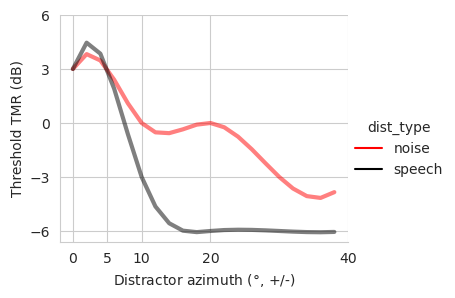

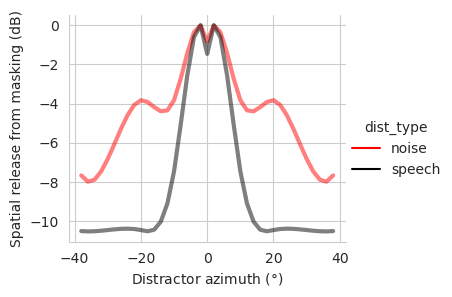

In [ ]:

sns.set_style('whitegrid')

## Plot as differece between max threshold and threshold 

## spline interpolate thresholds 
from scipy.interpolate import interp1d,  splev, splrep

# get threshold for each target azimuth and dist_type
thresholds = []
for (azim, dist_type), group in to_plot.groupby(['distractor_azim', 'dist_type']):
    # get the snr where performance is 50% max clean speech performance
    thresh = group[group.accuracy_mean >= 0.41].snr.min()
    thresholds.append((azim, dist_type, thresh))

thresholds = pd.DataFrame(thresholds, columns=['distractor_azim', 'dist_type', 'threshold_snr'])
thresholds['threshold_snr'] = thresholds['threshold_snr'].astype(int)
thresholds['distractor_azim'] = thresholds['distractor_azim'].astype(int)
# interpolate thresholds per dist type

interp_thresholds = []
for dist_type, group in thresholds.groupby('dist_type'):
    # print(group)
    # interp_threshold =  interp1d(group.distractor_azim, group.threshold_snr, kind='cubic')(np.arange(0, 40))
    new_azims = np.arange(0, 40, 2)
    spline = splrep(group.distractor_azim, group.threshold_snr)
    interp_threshold = splev(new_azims, spline)
    max_interp_threshold = interp_threshold.max()
    srm_interp_threshold = interp_threshold - max_interp_threshold
    group_list = (new_azims, interp_threshold, srm_interp_threshold, [dist_type] * len(new_azims))
    df = pd.DataFrame(np.array(group_list).T, columns=['distractor_azim', 'threshold_snr_interp', 'srm_interp', 'dist_type'])
    interp_thresholds.append(df)
interp_thresholds = pd.concat(interp_thresholds, ignore_index=True)
interp_thresholds['threshold_snr_interp'] = interp_thresholds['threshold_snr_interp'].astype(float)
interp_thresholds['distractor_azim'] = interp_thresholds['distractor_azim'].astype(float)
interp_thresholds['srm_interp'] = interp_thresholds['srm_interp'].astype(float)


## add azimuth values for symmetric distractors to thresholds df 
sym_thresholds = interp_thresholds[interp_thresholds.distractor_azim > 0].copy()
sym_thresholds['distractor_azim'] = sym_thresholds['distractor_azim'] * -1
interp_thresholds = pd.concat([interp_thresholds, sym_thresholds])
# print(thresholds)

g = sns.relplot(data=interp_thresholds[interp_thresholds.distractor_azim >=0],
                 x='distractor_azim', y='threshold_snr_interp', kind='line',
                hue='dist_type', palette=palette, alpha=0.5,
                 linewidth=3, zorder=5, errorbar=('se', 2), height=3, aspect=1.25)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-6,  6.1, 3), xticks=[0, 5, 10, 20, 40])


g = sns.relplot(data=interp_thresholds, x='distractor_azim', y='srm_interp', kind='line',
                hue='dist_type', palette=palette, alpha=0.5,
                 linewidth=3, zorder=5, errorbar=('se', 2), height=3, aspect=1.25)

g.set_axis_labels("Distractor azimuth ($\degree$)", "Spatial release from masking (dB)")
# g.set_titles("{col_name}")

# plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
# g.set(yticks=np.arange(-15, 3.1, 3), xticks=[-40, -20, -10, 0, 10, 20, 40])
# g.legend.remove()

# x_tick_locs = np.sort(thresholds.distractor_azim.unique())
# x_tick_labels = [str(x) for x in x_tick_locs]
# for ax in g.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(ticks=x_tick_locs) # set new labels
#     ax.set_xticklabels(labels=x_tick_labels)

Text(0.5, 1.05, 'Symmetric distractor positions')

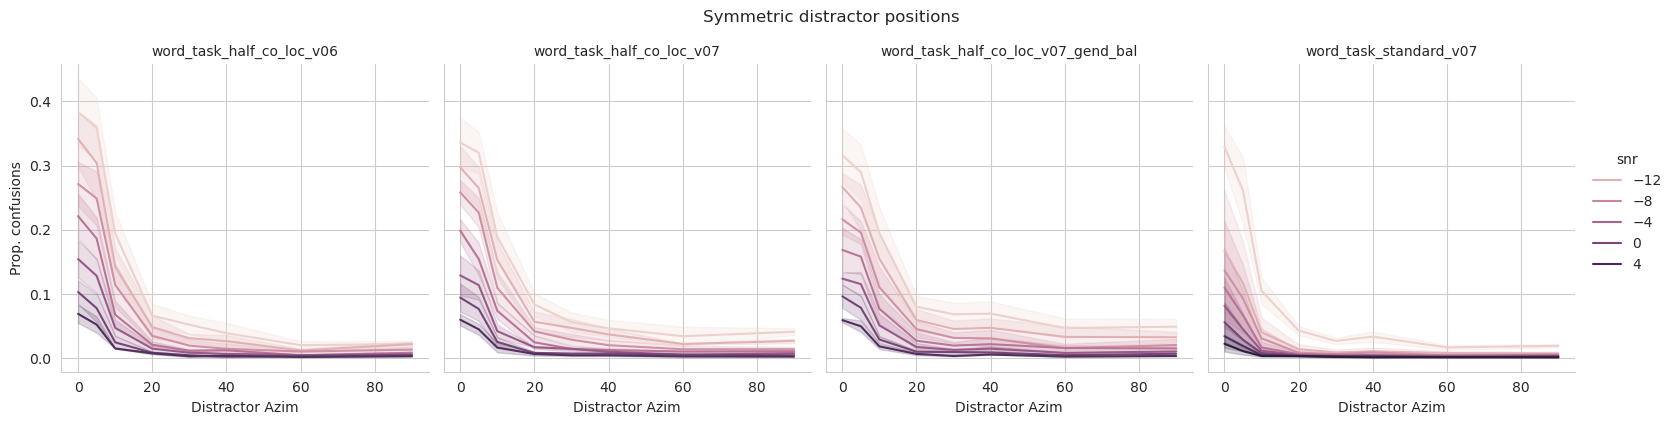

In [ ]:
### Plot diotic precedense effect 


# hue_order = ['clean', 'overlap', 'left', 'right', 'center']
# 
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results.copy() #& (grouped_results.target_azim == 'center')]
# to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
# to_plot = to_plot[to_plot.snr >= -6]
# to_plot = to_plot[to_plot.snr >= -6]
to_plot['distractor_azim'] = to_plot['distractor_azim'].astype(int).abs()

g = sns.relplot(data=to_plot,
                #palette=palette,
                x='distractor_azim', y='confusions_mean', errorbar=('se', 1), hue="snr",
                kind='line', legend=True,
                col='model',
                # palette=palette, 
             height=4)
# iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim']==azim]
#     # select the data for each hue group
#     for group, selected in data.groupby('diotic_cond'):
#         if group != 'clean':
#             continue
#         # plot the errorbar with the correct color for each group 
#         print(group)
#         ax.errorbar(data=selected, x="snr", y="confusions_mean",
#                      yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("Distractor Azim", "Prop. confusions")
g.set_titles("{col_name}")
plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
# g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

# x_tick_locs = np.sort(to_plot.snr.unique())
# x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
# for ax in g.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(ticks=x_tick_locs) # set new labels
#     ax.set_xticklabels(labels=x_tick_labels)
# plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')